In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from statistics import mean, stdev

In [2]:
sns.set_style('darkgrid')
cmap=sns.light_palette("seagreen",as_cmap=True)
pd.set_option('display.float_format','{:.4f}'.format)

# Read data

In [3]:
vanilla = pd.read_csv('adult-mpa-cat-wout-agg-vanilla_lr-100.csv', index_col=0)
zhang = pd.read_csv('adult-mpa-cat-wout-agg-mult_adv-100.csv', index_col=0)

In [4]:
vanilla

,model_name,cv_seed,clas_acc,f1-micro,f1-macro,a1_dp,a1_deqodds,a1_deqopp,a2_dp,a2_deqodds,a2_deqopp,wc_spd,wc_aod,wc_eod
0,SkVanillaLR,13,0.8413,0.8413,0.7676,0.8194,0.8857,0.8486,0.1737,0.2738,0.1737,0.6993,0.5855,0.1875
1,SkVanillaLR,29,0.8409,0.8409,0.7685,0.8146,0.8804,0.8400,0.2038,0.2649,0.2038,0.6771,0.5446,0.0833
2,SkVanillaLR,42,0.8442,0.8442,0.7773,0.8021,0.8808,0.8492,0.2213,0.3072,0.2213,0.6546,0.6371,0.4414
3,SkVanillaLR,55,0.8380,0.8380,0.7626,0.8281,0.8963,0.8597,0.1713,0.2751,0.1713,0.7215,0.6982,0.4190
4,SkVanillaLR,73,0.8372,0.8372,0.7674,0.8093,0.8920,0.8668,0.1609,0.2027,0.1609,0.7155,0.6326,0.2500


In [5]:
zhang

,model_name,cv_seed,clas_acc,f1-micro,f1-macro,a1_dp,a1_deqodds,a1_deqopp,a2_dp,a2_deqodds,a2_deqopp,wc_spd,wc_aod,wc_eod,last_cosine_similarity
0,MultAdvCat4DP,13,0.8348,0.8348,0.7721,0.7998,0.9020,0.9077,0.2201,0.3393,0.2201,0.6871,0.5982,0.3472,-0.0271
1,MultAdvCat4DP,29,0.8308,0.8308,0.7676,0.7884,0.8786,0.8683,0.2157,0.3192,0.2157,0.6922,0.5417,0.0833,-0.0178
2,MultAdvCat4DP,42,0.8337,0.8337,0.7749,0.7866,0.8977,0.9068,0.2486,0.4163,0.2486,0.6677,0.5768,0.3161,-0.0765
3,MultAdvCat4DP,55,0.8324,0.8324,0.7701,0.7980,0.8936,0.8861,0.2273,0.3588,0.2273,0.6876,0.5999,0.3453,-0.0463
4,MultAdvCat4DP,73,0.8335,0.8335,0.7739,0.7847,0.8833,0.8713,0.2416,0.3812,0.2416,0.6744,0.5879,0.3290,-0.0873
5,MultAdvCat4EqOdds,13,0.8365,0.8365,0.7740,0.8010,0.9036,0.9090,0.2190,0.3387,0.2190,0.6888,0.5993,0.3468,-0.0034
6,MultAdvCat4EqOdds,29,0.8319,0.8319,0.7689,0.7908,0.8817,0.8715,0.2165,0.3156,0.2165,0.6929,0.5417,0.0833,-0.1149
7,MultAdvCat4EqOdds,42,0.8340,0.8340,0.7754,0.7862,0.8991,0.9104,0.2496,0.4358,0.2496,0.6667,0.5756,0.3141,-0.1100
8,MultAdvCat4EqOdds,55,0.8323,0.8323,0.7697,0.7989,0.8948,0.8882,0.2263,0.3492,0.2263,0.6889,0.6014,0.3472,-0.0917
9,MultAdvCat4EqOdds,73,0.8322,0.8322,0.7724,0.7845,0.8873,0.8821,0.2433,0.3774,0.2433,0.6724,0.5866,0.3297,-0.1713


In [6]:
zhang[["model_name", "cv_seed", "last_cosine_similarity"]]

,model_name,cv_seed,last_cosine_similarity
0,MultAdvCat4DP,13,-0.0271
1,MultAdvCat4DP,29,-0.0178
2,MultAdvCat4DP,42,-0.0765
3,MultAdvCat4DP,55,-0.0463
4,MultAdvCat4DP,73,-0.0873
5,MultAdvCat4EqOdds,13,-0.0034
6,MultAdvCat4EqOdds,29,-0.1149
7,MultAdvCat4EqOdds,42,-0.1100
8,MultAdvCat4EqOdds,55,-0.0917
9,MultAdvCat4EqOdds,73,-0.1713


# Predictive performance

## Acc mean and std

In [6]:
vanilla_acc = vanilla.groupby(['model_name'])['clas_acc'].agg([mean, stdev])
zhang_acc = zhang.groupby(['model_name'])['clas_acc'].agg([mean, stdev])

In [7]:
acc = pd.concat([vanilla_acc, zhang_acc])
acc = acc.reset_index()
acc = acc.rename(columns={'index': 'model_name'})
acc

,model_name,mean,stdev
0,SkVanillaLR,0.8403,0.0028
1,MultAdv4EqOpp,0.8320,0.0019
2,MultAdvCat4DP,0.8330,0.0015
3,MultAdvCat4EqOdds,0.8334,0.0019


In [8]:
names = acc['model_name'].to_list()
for i in range(len(names)):
    if isinstance(names[i], tuple):
        names[i] = '-'.join([str(value) for value in names[i]])

names

['SkVanillaLR', 'MultAdv4EqOpp', 'MultAdvCat4DP', 'MultAdvCat4EqOdds']

In [9]:
acc['model_name'] = names
acc

,model_name,mean,stdev
0,SkVanillaLR,0.8403,0.0028
1,MultAdv4EqOpp,0.8320,0.0019
2,MultAdvCat4DP,0.8330,0.0015
3,MultAdvCat4EqOdds,0.8334,0.0019


In [10]:
print((acc['mean'].round(4).astype(str) + ' $\pm$ ' + acc['stdev'].round(4).astype(str)).to_string(index=False))

0.8403 $\pm$ 0.0028
 0.832 $\pm$ 0.0019
 0.833 $\pm$ 0.0015
0.8334 $\pm$ 0.0019


## Micro-f1 mean and std

In [11]:
vanilla_micro = vanilla.groupby(['model_name'])['f1-micro'].agg([mean, stdev])
zhang_micro = zhang.groupby(['model_name'])['f1-micro'].agg([mean, stdev])

In [12]:
micro = pd.concat([vanilla_micro, zhang_micro])
micro = micro.reset_index()
micro = micro.rename(columns={'index': 'model_name'})
micro

,model_name,mean,stdev
0,SkVanillaLR,0.8403,0.0028
1,MultAdv4EqOpp,0.8320,0.0019
2,MultAdvCat4DP,0.8330,0.0015
3,MultAdvCat4EqOdds,0.8334,0.0019


In [13]:
micro['model_name'] = names
micro

,model_name,mean,stdev
0,SkVanillaLR,0.8403,0.0028
1,MultAdv4EqOpp,0.8320,0.0019
2,MultAdvCat4DP,0.8330,0.0015
3,MultAdvCat4EqOdds,0.8334,0.0019


In [14]:
print((micro['mean'].round(4).astype(str) + ' $\pm$ ' + micro['stdev'].round(4).astype(str)).to_string(index=False))

0.8403 $\pm$ 0.0028
 0.832 $\pm$ 0.0019
 0.833 $\pm$ 0.0015
0.8334 $\pm$ 0.0019


## Macro-f1 mean and std

In [15]:
vanilla_macro = vanilla.groupby(['model_name'])['f1-macro'].agg([mean, stdev])
zhang_macro = zhang.groupby(['model_name'])['f1-macro'].agg([mean, stdev])

In [16]:
macro = pd.concat([vanilla_macro, zhang_macro])
macro = macro.reset_index()
macro = macro.rename(columns={'index': 'model_name'})
macro

,model_name,mean,stdev
0,SkVanillaLR,0.7687,0.0053
1,MultAdv4EqOpp,0.7710,0.0042
2,MultAdvCat4DP,0.7717,0.0030
3,MultAdvCat4EqOdds,0.7721,0.0028


In [17]:
macro['model_name'] = names
macro

,model_name,mean,stdev
0,SkVanillaLR,0.7687,0.0053
1,MultAdv4EqOpp,0.7710,0.0042
2,MultAdvCat4DP,0.7717,0.0030
3,MultAdvCat4EqOdds,0.7721,0.0028


In [18]:
print((macro['mean'].round(4).astype(str) + ' $\pm$ ' + macro['stdev'].round(4).astype(str)).to_string(index=False))

0.7687 $\pm$ 0.0053
 0.771 $\pm$ 0.0042
 0.7717 $\pm$ 0.003
0.7721 $\pm$ 0.0028


# Group fairness for first protected attribute

## DP mean and std

In [19]:
vanilla_dp = vanilla.groupby(['model_name'])['a1_dp'].agg([mean, stdev])
zhang_dp = zhang.groupby(['model_name'])['a1_dp'].agg([mean, stdev])

In [20]:
dp = pd.concat([vanilla_dp, zhang_dp])
dp = dp.reset_index()
dp = dp.rename(columns={'index': 'model_name'})
dp['model_name'] = names
dp

,model_name,mean,stdev
0,SkVanillaLR,0.8147,0.0098
1,MultAdv4EqOpp,0.7858,0.0095
2,MultAdvCat4DP,0.7915,0.0069
3,MultAdvCat4EqOdds,0.7923,0.0074


In [21]:
print((dp['mean'].round(4).astype(str) + ' $\pm$ ' + dp['stdev'].round(4).astype(str)).to_string(index=False))

0.8147 $\pm$ 0.0098
0.7858 $\pm$ 0.0095
0.7915 $\pm$ 0.0069
0.7923 $\pm$ 0.0074


## DEqOdds mean and std

In [22]:
vanilla_deqodds = vanilla.groupby(['model_name'])['a1_deqodds'].agg([mean, stdev])
zhang_deqodds = zhang.groupby(['model_name'])['a1_deqodds'].agg([mean, stdev])

In [23]:
deqodds = pd.concat([vanilla_deqodds, zhang_deqodds])
deqodds = deqodds.reset_index()
deqodds = deqodds.rename(columns={'index': 'model_name'})
deqodds['model_name'] = names
deqodds

,model_name,mean,stdev
0,SkVanillaLR,0.8870,0.0070
1,MultAdv4EqOpp,0.8830,0.0113
2,MultAdvCat4DP,0.8910,0.0098
3,MultAdvCat4EqOdds,0.8933,0.0088


In [24]:
print((deqodds['mean'].round(4).astype(str) + ' $\pm$ ' + deqodds['stdev'].round(4).astype(str)).to_string(index=False))

  0.887 $\pm$ 0.007
 0.883 $\pm$ 0.0113
 0.891 $\pm$ 0.0098
0.8933 $\pm$ 0.0088


## DEqOpp mean and std

In [25]:
vanilla_deqopp = vanilla.groupby(['model_name'])['a1_deqopp'].agg([mean, stdev])
zhang_deqopp = zhang.groupby(['model_name'])['a1_deqopp'].agg([mean, stdev])

In [26]:
deqopp = pd.concat([vanilla_deqopp, zhang_deqopp])
deqopp = deqopp.reset_index()
deqopp = deqopp.rename(columns={'index': 'model_name'})
deqopp['model_name'] = names
deqopp

,model_name,mean,stdev
0,SkVanillaLR,0.8529,0.0105
1,MultAdv4EqOpp,0.8772,0.0208
2,MultAdvCat4DP,0.8880,0.0188
3,MultAdvCat4EqOdds,0.8922,0.0170


In [27]:
print((deqopp['mean'].round(4).astype(str) + ' $\pm$ ' + deqopp['stdev'].round(4).astype(str)).to_string(index=False))

0.8529 $\pm$ 0.0105
0.8772 $\pm$ 0.0208
 0.888 $\pm$ 0.0188
 0.8922 $\pm$ 0.017


# Group fairness for second protected attribute

## DP mean and std

In [28]:
vanilla_dp = vanilla.groupby(['model_name'])['a2_dp'].agg([mean, stdev])
zhang_dp = zhang.groupby(['model_name'])['a2_dp'].agg([mean, stdev])

In [29]:
dp = pd.concat([vanilla_dp, zhang_dp])
dp = dp.reset_index()
dp = dp.rename(columns={'index': 'model_name'})
dp['model_name'] = names
dp

,model_name,mean,stdev
0,SkVanillaLR,0.1862,0.0253
1,MultAdv4EqOpp,0.2343,0.0145
2,MultAdvCat4DP,0.2307,0.0140
3,MultAdvCat4EqOdds,0.2309,0.0148


In [30]:
print((dp['mean'].round(4).astype(str) + ' $\pm$ ' + dp['stdev'].round(4).astype(str)).to_string(index=False))

0.1862 $\pm$ 0.0253
0.2343 $\pm$ 0.0145
 0.2307 $\pm$ 0.014
0.2309 $\pm$ 0.0148


## DEqOdds mean and std

In [31]:
vanilla_deqodds = vanilla.groupby(['model_name'])['a2_deqodds'].agg([mean, stdev])
zhang_deqodds = zhang.groupby(['model_name'])['a2_deqodds'].agg([mean, stdev])

In [32]:
deqodds = pd.concat([vanilla_deqodds, zhang_deqodds])
deqodds = deqodds.reset_index()
deqodds = deqodds.rename(columns={'index': 'model_name'})
deqodds['model_name'] = names
deqodds

,model_name,mean,stdev
0,SkVanillaLR,0.2647,0.0382
1,MultAdv4EqOpp,0.3668,0.0405
2,MultAdvCat4DP,0.3629,0.0376
3,MultAdvCat4EqOdds,0.3633,0.0462


In [33]:
print((deqodds['mean'].round(4).astype(str) + ' $\pm$ ' + deqodds['stdev'].round(4).astype(str)).to_string(index=False))

0.2647 $\pm$ 0.0382
0.3668 $\pm$ 0.0405
0.3629 $\pm$ 0.0376
0.3633 $\pm$ 0.0462


## DEqOpp mean and std

In [34]:
vanilla_deqopp = vanilla.groupby(['model_name'])['a2_deqopp'].agg([mean, stdev])
zhang_deqopp = zhang.groupby(['model_name'])['a2_deqopp'].agg([mean, stdev])

In [35]:
deqopp = pd.concat([vanilla_deqopp, zhang_deqopp])
deqopp = deqopp.reset_index()
deqopp = deqopp.rename(columns={'index': 'model_name'})
deqopp['model_name'] = names
deqopp

,model_name,mean,stdev
0,SkVanillaLR,0.1862,0.0253
1,MultAdv4EqOpp,0.2343,0.0145
2,MultAdvCat4DP,0.2307,0.0140
3,MultAdvCat4EqOdds,0.2309,0.0148


In [36]:
print((deqopp['mean'].round(4).astype(str) + ' $\pm$ ' + deqopp['stdev'].round(4).astype(str)).to_string(index=False))

0.1862 $\pm$ 0.0253
0.2343 $\pm$ 0.0145
 0.2307 $\pm$ 0.014
0.2309 $\pm$ 0.0148


# Intersectional Fairness

## WCSPD mean and std

In [37]:
vanilla_wcspd = vanilla.groupby(['model_name'])['wc_spd'].agg([mean, stdev])
zhang_wcspd = zhang.groupby(['model_name'])['wc_spd'].agg([mean, stdev])

In [38]:
wcspd = pd.concat([vanilla_wcspd, zhang_wcspd])
wcspd = wcspd.reset_index()
wcspd = wcspd.rename(columns={'index': 'model_name'})
wcspd['model_name'] = names
wcspd

,model_name,mean,stdev
0,SkVanillaLR,0.6936,0.0278
1,MultAdv4EqOpp,0.6753,0.0108
2,MultAdvCat4DP,0.6818,0.0103
3,MultAdvCat4EqOdds,0.6819,0.0116


In [39]:
print((wcspd['mean'].round(4).astype(str) + ' $\pm$ ' + wcspd['stdev'].round(4).astype(str)).to_string(index=False))

0.6936 $\pm$ 0.0278
0.6753 $\pm$ 0.0108
0.6818 $\pm$ 0.0103
0.6819 $\pm$ 0.0116


## WCAOD mean and std

In [40]:
vanilla_wcaod = vanilla.groupby(['model_name'])['wc_aod'].agg([mean, stdev])
zhang_wcaod = zhang.groupby(['model_name'])['wc_aod'].agg([mean, stdev])

In [41]:
wcaod = pd.concat([vanilla_wcaod, zhang_wcaod])
wcaod = wcaod.reset_index()
wcaod = wcaod.rename(columns={'index': 'model_name'})
wcaod['model_name'] = names
wcaod

,model_name,mean,stdev
0,SkVanillaLR,0.6196,0.0580
1,MultAdv4EqOpp,0.5781,0.0238
2,MultAdvCat4DP,0.5809,0.0238
3,MultAdvCat4EqOdds,0.5809,0.0243


In [42]:
print((wcaod['mean'].round(4).astype(str) + ' $\pm$ ' + wcaod['stdev'].round(4).astype(str)).to_string(index=False))

 0.6196 $\pm$ 0.058
0.5781 $\pm$ 0.0238
0.5809 $\pm$ 0.0238
0.5809 $\pm$ 0.0243


## WCEOD mean and std

In [43]:
vanilla_wceod = vanilla.groupby(['model_name'])['wc_eod'].agg([mean, stdev])
zhang_wceod = zhang.groupby(['model_name'])['wc_eod'].agg([mean, stdev])

In [44]:
wceod = pd.concat([vanilla_wceod, zhang_wceod])
wceod = wceod.reset_index()
wceod = wceod.rename(columns={'index': 'model_name'})
wceod['model_name'] = names
wceod

,model_name,mean,stdev
0,SkVanillaLR,0.2763,0.1528
1,MultAdv4EqOpp,0.2815,0.1121
2,MultAdvCat4DP,0.2842,0.1130
3,MultAdvCat4EqOdds,0.2842,0.1131


In [45]:
print((wceod['mean'].round(4).astype(str) + ' $\pm$ ' + wceod['stdev'].round(4).astype(str)).to_string(index=False))

0.2763 $\pm$ 0.1528
0.2815 $\pm$ 0.1121
 0.2842 $\pm$ 0.113
0.2842 $\pm$ 0.1131


# T-test

In [46]:
vanilla_lr = vanilla
zhang4dp, zhang4deqodds, zhang4deqopp = [x for _, x in zhang.groupby(['model_name'])]

In [47]:
models = [
    vanilla_lr,
    zhang4dp, zhang4deqodds, zhang4deqopp
]

In [48]:
alpha = 0.05 # significance level
confidence = 1 - alpha # confidence level
l = len(models)

In [49]:
base_df = pd.DataFrame(index=names, columns=names, dtype=object)

## for accuracies

In [50]:
res_acc = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['clas_acc'], models[j]['clas_acc'])
        res_acc.iloc[i, j] = stat[1]

In [51]:
res_acc.T.fillna('-')

,SkVanillaLR,MultAdv4EqOpp,MultAdvCat4DP,MultAdvCat4EqOdds
SkVanillaLR,-,-,-,-
MultAdv4EqOpp,0.0031,-,-,-
MultAdvCat4DP,0.0051,0.0487,-,-
MultAdvCat4EqOdds,0.0033,0.1462,0.5071,-


In [52]:
res_acc = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['f1-micro'], models[j]['f1-micro'])
        res_acc.iloc[i, j] = stat[1]

In [53]:
res_acc.T.fillna('-')

,SkVanillaLR,MultAdv4EqOpp,MultAdvCat4DP,MultAdvCat4EqOdds
SkVanillaLR,-,-,-,-
MultAdv4EqOpp,0.0031,-,-,-
MultAdvCat4DP,0.0051,0.0487,-,-
MultAdvCat4EqOdds,0.0033,0.1462,0.5071,-


In [54]:
res_acc = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['f1-macro'], models[j]['f1-macro'])
        res_acc.iloc[i, j] = stat[1]

In [55]:
res_acc.T.fillna('-')

,SkVanillaLR,MultAdv4EqOpp,MultAdvCat4DP,MultAdvCat4EqOdds
SkVanillaLR,-,-,-,-
MultAdv4EqOpp,0.2749,-,-,-
MultAdvCat4DP,0.2035,0.3576,-,-
MultAdvCat4EqOdds,0.1246,0.3689,0.5453,-


## for group fairness A1

In [56]:
res_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a1_dp'], models[j]['a1_dp'])
        res_dp.iloc[i, j] = stat[1]

In [57]:
res_dp.T.fillna('-')

,SkVanillaLR,MultAdv4EqOpp,MultAdvCat4DP,MultAdvCat4EqOdds
SkVanillaLR,-,-,-,-
MultAdv4EqOpp,0.0001,-,-,-
MultAdvCat4DP,0.0008,0.0170,-,-
MultAdvCat4EqOdds,0.0007,0.0105,0.2105,-


In [58]:
res_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a1_deqodds'], models[j]['a1_deqodds'])
        res_deqodds.iloc[i, j] = stat[1]

In [59]:
res_deqodds.T.fillna('')

,SkVanillaLR,MultAdv4EqOpp,MultAdvCat4DP,MultAdvCat4EqOdds
SkVanillaLR,,,,
MultAdv4EqOpp,0.4849,,,
MultAdvCat4DP,0.4924,0.0050,,
MultAdvCat4EqOdds,0.2719,0.0025,0.0153,


In [60]:
res_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a1_deqopp'], models[j]['a1_deqopp'])
        res_deqopp.iloc[i, j] = stat[1]

In [61]:
res_deqopp.T.fillna('')

,SkVanillaLR,MultAdv4EqOpp,MultAdvCat4DP,MultAdvCat4EqOdds
SkVanillaLR,,,,
MultAdv4EqOpp,0.0833,,,
MultAdvCat4DP,0.0272,0.0056,,
MultAdvCat4EqOdds,0.0127,0.0030,0.0684,


## for group fairness A2

In [62]:
res_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a2_dp'], models[j]['a2_dp'])
        res_dp.iloc[i, j] = stat[1]

In [63]:
res_dp.T.fillna('-')

,SkVanillaLR,MultAdv4EqOpp,MultAdvCat4DP,MultAdvCat4EqOdds
SkVanillaLR,-,-,-,-
MultAdv4EqOpp,0.0167,-,-,-
MultAdvCat4DP,0.0199,0.0178,-,-
MultAdvCat4EqOdds,0.0197,0.0403,0.6702,-


In [64]:
res_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a2_deqodds'], models[j]['a2_deqodds'])
        res_deqodds.iloc[i, j] = stat[1]

In [65]:
res_deqodds.T.fillna('')

,SkVanillaLR,MultAdv4EqOpp,MultAdvCat4DP,MultAdvCat4EqOdds
SkVanillaLR,,,,
MultAdv4EqOpp,0.0095,,,
MultAdvCat4DP,0.0113,0.4543,,
MultAdvCat4EqOdds,0.0131,0.6723,0.9409,


In [66]:
res_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a2_deqopp'], models[j]['a2_deqopp'])
        res_deqopp.iloc[i, j] = stat[1]

In [67]:
res_deqopp.T.fillna('')

,SkVanillaLR,MultAdv4EqOpp,MultAdvCat4DP,MultAdvCat4EqOdds
SkVanillaLR,,,,
MultAdv4EqOpp,0.0167,,,
MultAdvCat4DP,0.0199,0.0178,,
MultAdvCat4EqOdds,0.0197,0.0403,0.6702,


## for intersectional fairness

In [68]:
res_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['wc_spd'], models[j]['wc_spd'])
        res_dp.iloc[i, j] = stat[1]

In [69]:
res_dp.T.fillna('-')

,SkVanillaLR,MultAdv4EqOpp,MultAdvCat4DP,MultAdvCat4EqOdds
SkVanillaLR,-,-,-,-
MultAdv4EqOpp,0.2122,-,-,-
MultAdvCat4DP,0.3656,0.0198,-,-
MultAdvCat4EqOdds,0.3754,0.0268,0.8414,-


In [70]:
res_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['wc_aod'], models[j]['wc_aod'])
        res_deqodds.iloc[i, j] = stat[1]

In [71]:
res_deqodds.T.fillna('-')

,SkVanillaLR,MultAdv4EqOpp,MultAdvCat4DP,MultAdvCat4EqOdds
SkVanillaLR,-,-,-,-
MultAdv4EqOpp,0.1085,-,-,-
MultAdvCat4DP,0.1246,0.1502,-,-
MultAdvCat4EqOdds,0.1249,0.0646,0.9841,-


In [72]:
res_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['wc_eod'], models[j]['wc_eod'])
        res_deqopp.iloc[i, j] = stat[1]

In [73]:
res_deqopp.T.fillna('-')

,SkVanillaLR,MultAdv4EqOpp,MultAdvCat4DP,MultAdvCat4EqOdds
SkVanillaLR,-,-,-,-
MultAdv4EqOpp,0.9245,-,-,-
MultAdvCat4DP,0.8847,0.3082,-,-
MultAdvCat4EqOdds,0.8840,0.2476,0.9193,-


# Plotting

## Plotting Accuracies

In [74]:
model_names = vanilla['model_name'].to_list()
model_names += zhang['model_name'].to_list()

In [75]:
model_names

['SkVanillaLR',
 'SkVanillaLR',
 'SkVanillaLR',
 'SkVanillaLR',
 'SkVanillaLR',
 'MultAdvCat4DP',
 'MultAdvCat4DP',
 'MultAdvCat4DP',
 'MultAdvCat4DP',
 'MultAdvCat4DP',
 'MultAdvCat4EqOdds',
 'MultAdvCat4EqOdds',
 'MultAdvCat4EqOdds',
 'MultAdvCat4EqOdds',
 'MultAdvCat4EqOdds',
 'MultAdv4EqOpp',
 'MultAdv4EqOpp',
 'MultAdv4EqOpp',
 'MultAdv4EqOpp',
 'MultAdv4EqOpp']

In [76]:
model_accs = vanilla['clas_acc'].to_list()+zhang['clas_acc'].to_list()

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_25970/1516234898.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


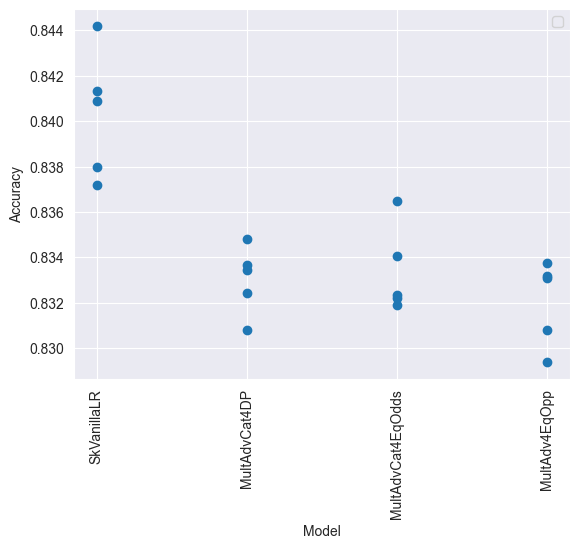

In [77]:
plt.plot()
plt.ylabel('Accuracy')

plt.scatter(model_names, model_accs)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Demographic Disparities

In [78]:
model_spd = vanilla['wc_spd'].to_list()+zhang['wc_spd'].to_list()

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_25970/545090117.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


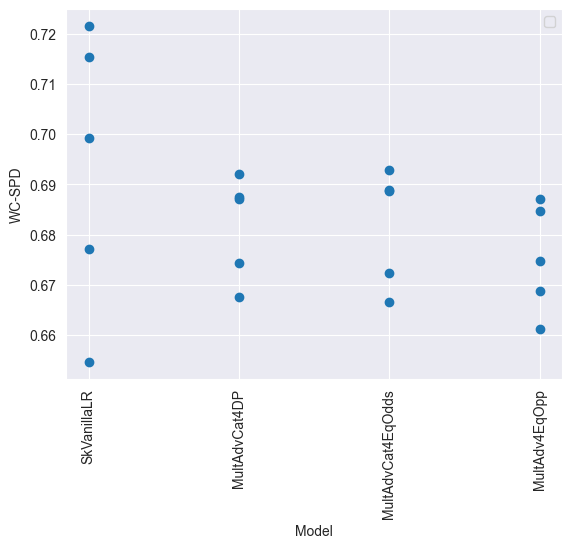

In [79]:
plt.plot()
plt.ylabel('WC-SPD')

plt.scatter(model_names, model_spd)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Disparity in Equal Odds

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_25970/1727290324.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


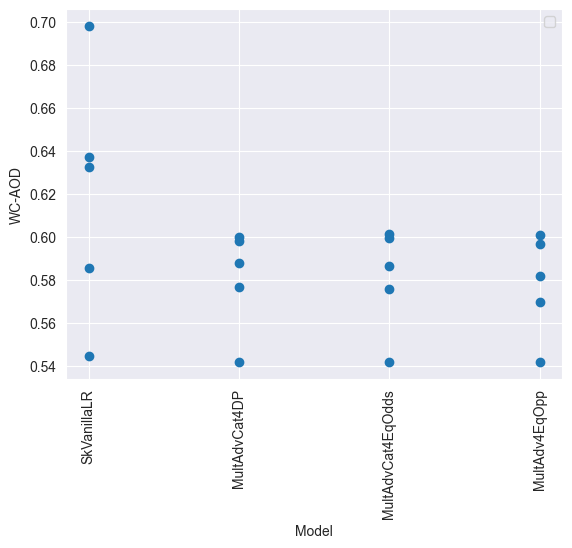

In [80]:
model_aod = vanilla['wc_aod'].to_list()+zhang['wc_aod'].to_list()
plt.plot()
plt.ylabel('WC-AOD')

plt.scatter(model_names, model_aod)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Disparity in Equal Opp

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_25970/2617305754.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


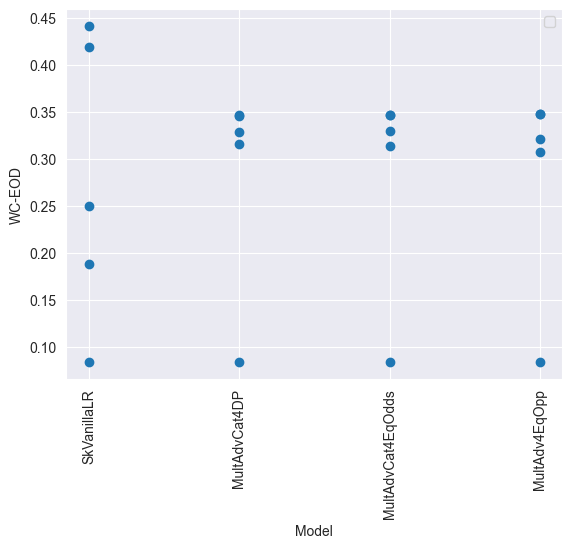

In [81]:
model_eod = vanilla['wc_eod'].to_list()+zhang['wc_eod'].to_list()
plt.plot()
plt.ylabel('WC-EOD')

plt.scatter(model_names, model_eod)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Acc x WC-SPD

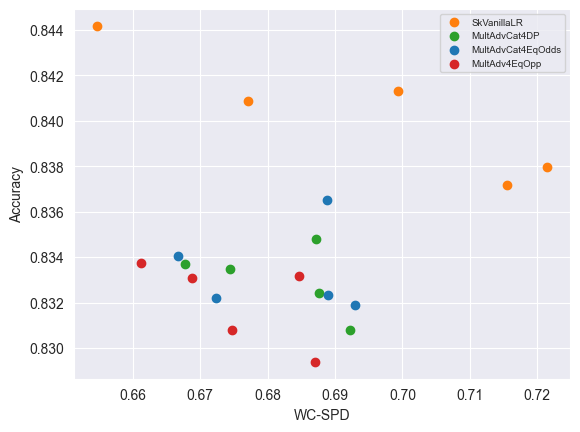

<Figure size 700x700 with 0 Axes>

In [82]:
plt.plot()
#sns.light_palette("seagreen",as_cmap=True)

#fig, ax = plt.scatter(model_dps, model_accs)#, label = "ZHANG DemPar")
'''fig, ax = plt.subplots()
ax.scatter(model_dps, model_accs)'''

# assign one color per model
unique_models = list(set(model_names))
cmap = plt.get_cmap('tab10')
color_dict = {
    model: cmap(i % 10)
    for i, model in enumerate(unique_models)
}

plt.xlabel('WC-SPD')
plt.ylabel('Accuracy')

seen = set()

for i, model_name in enumerate(model_names):
    label = model_name if model_name not in seen else None
    seen.add(model_name)
    plt.scatter(
        model_spd[i],
        model_accs[i],
        label=label,
        color=color_dict[model_name]
    )
plt.legend(fontsize='x-small')
plt.figure(figsize=(7,7))

plt.show()

## Plotting Acc x WC-AOD

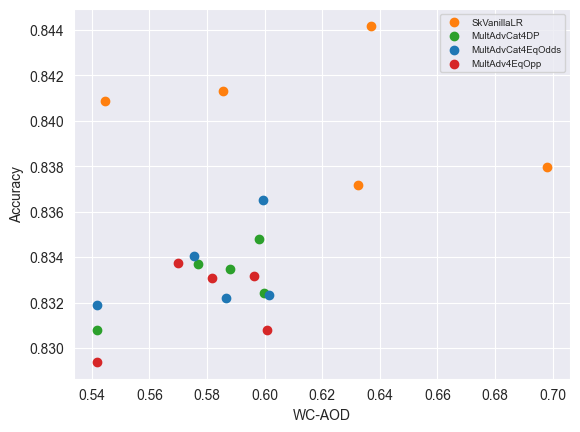

<Figure size 700x700 with 0 Axes>

In [83]:
plt.plot()
#sns.light_palette("seagreen",as_cmap=True)

#fig, ax = plt.scatter(model_dps, model_accs)#, label = "ZHANG DemPar")
'''fig, ax = plt.subplots()
ax.scatter(model_dps, model_accs)'''

# assign one color per model
unique_models = list(set(model_names))
cmap = plt.get_cmap('tab10')
color_dict = {
    model: cmap(i % 10)
    for i, model in enumerate(unique_models)
}

plt.xlabel('WC-AOD')
plt.ylabel('Accuracy')

seen = set()

for i, model_name in enumerate(model_names):
    label = model_name if model_name not in seen else None
    seen.add(model_name)
    plt.scatter(
        model_aod[i],
        model_accs[i],
        label=label,
        color=color_dict[model_name]
    )
plt.legend(fontsize='x-small')
plt.figure(figsize=(7,7))

plt.show()

## Plotting Acc x WC-EOD

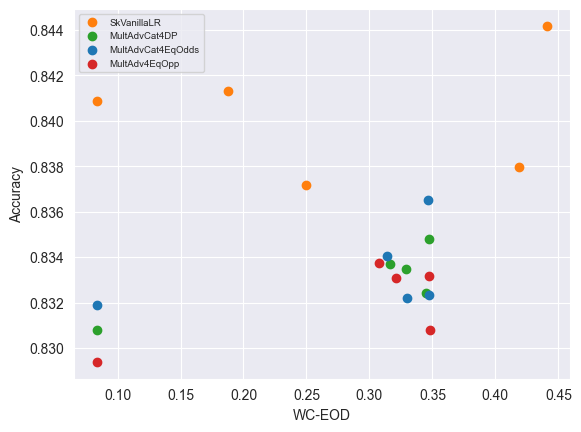

<Figure size 700x700 with 0 Axes>

In [84]:
plt.plot()
#sns.light_palette("seagreen",as_cmap=True)

#fig, ax = plt.scatter(model_dps, model_accs)#, label = "ZHANG DemPar")
'''fig, ax = plt.subplots()
ax.scatter(model_dps, model_accs)'''

# assign one color per model
unique_models = list(set(model_names))
cmap = plt.get_cmap('tab10')
color_dict = {
    model: cmap(i % 10)
    for i, model in enumerate(unique_models)
}

plt.xlabel('WC-EOD')
plt.ylabel('Accuracy')

seen = set()

for i, model_name in enumerate(model_names):
    label = model_name if model_name not in seen else None
    seen.add(model_name)
    plt.scatter(
        model_eod[i],
        model_accs[i],
        label=label,
        color=color_dict[model_name]
    )
plt.legend(fontsize='x-small')
plt.figure(figsize=(7,7))

plt.show()